<a href="https://colab.research.google.com/github/richiv4r3-crypto/MineriaDeDatos/blob/main/Clasificaci%C3%B3n_de_D%C3%ADgitos_Manuscritos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [6]:
# Carga del dataset
digits = load_digits()
X = digits.data
y = digits.target

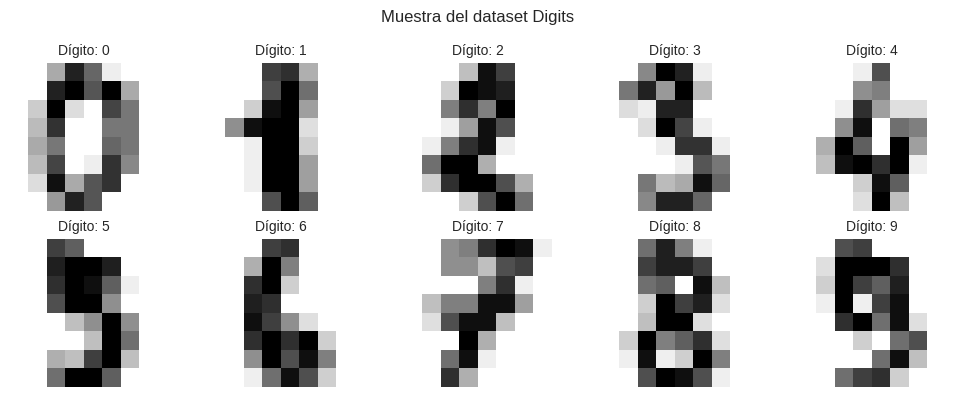

In [7]:
# Visualización de una muestra por clase
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    idx = np.where(y == i)[0][0]
    ax.imshow(digits.images[idx], cmap='gray_r')
    ax.set_title(f"Dígito: {i}", fontsize=10)
    ax.axis('off')
plt.suptitle("Muestra del dataset Digits", fontsize=12)
plt.tight_layout()
plt.show()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# La última expresión se muestra sola en Colab
{
    "Entrenamiento": X_train_s.shape[0],
    "Prueba": X_test_s.shape[0]
}

{'Entrenamiento': 1437, 'Prueba': 360}

In [9]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_s, y_train)

svm = SVC(kernel='rbf', C=10, gamma=0.001, random_state=42)
svm.fit(X_train_s, y_train)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_s, y_train)

RandomForestClassifier(random_state=42)

In [10]:
import pandas as pd

modelos = {'KNN (k=5)': knn, 'SVM (RBF)': svm, 'Random Forest': rf}
resultados = {}

for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test_s)
    resultados[nombre] = round(accuracy_score(y_test, y_pred), 4)

# DataFrame se renderiza como tabla visual en Colab
df_resultados = pd.DataFrame.from_dict(
    resultados, orient='index', columns=['Accuracy']
).sort_values('Accuracy', ascending=False)

df_resultados

,Accuracy
SVM (RBF),0.9889
KNN (k=5),0.9639
Random Forest,0.9639


In [11]:
# Reporte del mejor modelo
mejor = df_resultados.index[0]
y_pred_mejor = modelos[mejor].predict(X_test_s)

# classification_report como DataFrame
report = classification_report(y_test, y_pred_mejor, output_dict=True)
pd.DataFrame(report).T.round(2)

,precision,recall,f1-score,support
0,1.00,1.00,1.00,36.00
1,0.95,0.97,0.96,36.00
2,1.00,1.00,1.00,35.00
3,1.00,1.00,1.00,37.00
4,0.97,1.00,0.99,36.00
5,1.00,1.00,1.00,37.00
6,1.00,1.00,1.00,36.00
7,0.97,1.00,0.99,36.00
8,1.00,0.94,0.97,35.00
9,1.00,0.97,0.99,36.00


In [12]:
X_propio   = np.array([img.flatten() for img in imagenes])
X_propio_s = scaler.transform(X_propio)

filas = []
for i, (img_s, real) in enumerate(zip(X_propio_s, digito_real)):
    filas.append({
        "Imagen":  f"Imagen {i+1}",
        "Real":    real,
        "KNN":     knn.predict([img_s])[0],
        "SVM":     svm.predict([img_s])[0],
        "RF":      rf.predict([img_s])[0],
    })

pd.DataFrame(filas).set_index("Imagen")

NameError: name 'imagenes' is not defined